<a href="https://www.kaggle.com/code/kirahhayatdata/detection-for-cloud-security?scriptVersionId=324460717" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# IMPORT LIBRARIES & SETUP

In [1]:

from sklearn.preprocessing import MinMaxScaler


In [2]:
# ============================================================
# STEP 1 — IMPORT LIBRARIES & SETUP
# ============================================================

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Basic Libraries
import os
import glob
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Model Saving
import joblib

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Create Output Folders
os.makedirs('/kaggle/working/outputs', exist_ok=True)
os.makedirs('/kaggle/working/models', exist_ok=True)
os.makedirs('/kaggle/working/plots', exist_ok=True)

print("=" * 60)
print("STEP 1 COMPLETED SUCCESSFULLY")
print("=" * 60)
print("Folders Created:")
print("1. outputs/")
print("2. models/")
print("3. plots/")

STEP 1 COMPLETED SUCCESSFULLY
Folders Created:
1. outputs/
2. models/
3. plots/


# LOAD ALL CICIDS2017 CSV FILES AUTOMATICALLY

In [3]:
# ============================================================
# STEP 2 — LOAD ALL CICIDS2017 CSV FILES
# ============================================================

# Dataset Path
DATASET_PATH = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"

# Get All CSV Files
csv_files = glob.glob(os.path.join(DATASET_PATH, "*.csv"))

print("=" * 60)
print("TOTAL FILES FOUND:", len(csv_files))
print("=" * 60)

for file in csv_files:
    print(os.path.basename(file))


# Read and Merge All CSV Files
dataframes = []

print("\nLoading CSV files...\n")

for file in csv_files:
    try:
        df_temp = pd.read_csv(file, low_memory=False)

        print(f"Loaded: {os.path.basename(file)}")
        print(f"Shape: {df_temp.shape}")
        print("-" * 50)

        dataframes.append(df_temp)

    except Exception as e:
        print(f"Error reading {file}: {e}")


# Merge All Files
df = pd.concat(dataframes, ignore_index=True)

print("\n" + "=" * 60)
print("ALL FILES MERGED SUCCESSFULLY")
print("=" * 60)

print("Final Dataset Shape:", df.shape)


# Clean Column Names
df.columns = df.columns.str.strip()

print("\nColumns:")
print(df.columns.tolist())


# Check Target Column
print("\nTarget Column Unique Labels:")
print(df['Label'].value_counts())


# Save Raw Combined Dataset
raw_save_path = "/kaggle/working/outputs/raw_merged_dataset.csv"
df.to_csv(raw_save_path, index=False)

print("\nRaw Dataset Saved:")
print(raw_save_path)


# Dataset Basic Info
print("\nDataset Information")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum().sum())


# Show First 5 Rows
df.head()

TOTAL FILES FOUND: 8
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv

Loading CSV files...

Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Shape: (286467, 79)
--------------------------------------------------
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Shape: (170366, 79)
--------------------------------------------------
Loaded: Tuesday-WorkingHours.pcap_ISCX.csv
Shape: (445909, 79)
--------------------------------------------------
Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Shape: (225745, 79)
--------------------------------------------------
Loaded: Monday-WorkingHours.pcap_ISCX.csv
Shape: (529918, 79)
---------------------

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# DATA PREPROCESSING

In [4]:
# ============================================================
# STEP 3 — DATA PREPROCESSING
# ============================================================

print("=" * 60)
print("STARTING DATA PREPROCESSING")
print("=" * 60)

# -----------------------------
# 1. Remove Duplicates
# -----------------------------
print("\nRemoving duplicate rows...")

initial_rows = df.shape[0]

df.drop_duplicates(inplace=True)

final_rows = df.shape[0]

print(f"Removed {initial_rows - final_rows} duplicate rows")
print(f"Remaining rows: {final_rows}")


# -----------------------------
# 2. Handle Missing Values
# -----------------------------
print("\nChecking Missing Values...")

missing_values = df.isnull().sum().sum()

print("Total Missing Values:", missing_values)

if missing_values > 0:
    df.dropna(inplace=True)
    print("Missing values removed")
else:
    print("No missing values found")


# -----------------------------
# 3. Remove Infinity Values
# -----------------------------
print("\nHandling Infinity Values...")

df.replace([np.inf, -np.inf], np.nan, inplace=True)

before_drop = df.shape[0]

df.dropna(inplace=True)

after_drop = df.shape[0]

print(f"Removed {before_drop - after_drop} rows containing infinity values")


# -----------------------------
# 4. Clean Column Names
# -----------------------------
print("\nCleaning column names...")

df.columns = df.columns.str.strip()

print("Column names cleaned")


# -----------------------------
# 5. Binary Classification
# BENIGN = 0
# ATTACK = 1
# -----------------------------
print("\nConverting Labels to Binary...")

print("Original Labels:")
print(df['Label'].value_counts())


def convert_label(label):
    if label == 'BENIGN':
        return 0
    else:
        return 1


df['Target'] = df['Label'].apply(convert_label)

print("\nBinary Class Distribution:")
print(df['Target'].value_counts())


# -----------------------------
# 6. Remove Original Label
# -----------------------------
df.drop('Label', axis=1, inplace=True)


# -----------------------------
# 7. Encode Categorical Features
# -----------------------------
print("\nEncoding categorical columns...")

categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns Found:")
print(categorical_cols.tolist())

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

print("Categorical encoding completed")


# -----------------------------
# 8. Feature / Target Split
# -----------------------------
print("\nSplitting Features and Target...")

X = df.drop('Target', axis=1)
y = df['Target']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


# -----------------------------
# 9. Feature Scaling
# -----------------------------
print("\nApplying StandardScaler...")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Feature scaling completed")


# -----------------------------
# 10. Save Clean Dataset
# -----------------------------
cleaned_path = "/kaggle/working/outputs/cleaned_dataset.csv"

df.to_csv(cleaned_path, index=False)

print("\nCleaned Dataset Saved:")
print(cleaned_path)


# -----------------------------
# Final Summary
# -----------------------------
print("\n" + "=" * 60)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Final Dataset Shape:", df.shape)
print("Features Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

print("\nClass Distribution:")
print(y.value_counts())

print("\nFirst 5 Rows:")
display(df.head())

STARTING DATA PREPROCESSING

Removing duplicate rows...
Removed 308381 duplicate rows
Remaining rows: 2522362

Checking Missing Values...
Total Missing Values: 353
Missing values removed

Handling Infinity Values...
Removed 1211 rows containing infinity values

Cleaning column names...
Column names cleaned

Converting Labels to Binary...
Original Labels:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Binary Class Distribution:
Target
0    2

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Target
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0


# BALANCING + MIN-MAX NORMALIZATION

In [5]:
# ------------------------------------------------
# 7. CLASS BALANCING
# Random Undersampling
# ------------------------------------------------
print("\nBalancing dataset...")

benign_df = df[df['Target'] == 0]
attack_df = df[df['Target'] == 1]

minority_size = len(attack_df)

print("Minority Class Size:", minority_size)

benign_sampled = benign_df.sample(
    n=minority_size,
    random_state=SEED
)

balanced_df = pd.concat(
    [benign_sampled, attack_df],
    axis=0
)

balanced_df = balanced_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("\nBalanced Class Distribution:")
print(balanced_df['Target'].value_counts())


# ------------------------------------------------
# 8. Feature / Target Split
# ------------------------------------------------
X = balanced_df.drop('Target', axis=1)
y = balanced_df['Target']

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


# ------------------------------------------------
# 9. Min-Max Normalization
# ------------------------------------------------
print("\nApplying Min-Max Normalization...")

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Normalization completed")


# ------------------------------------------------
# 10. Save Processed Dataset
# ------------------------------------------------
balanced_save_path = "/kaggle/working/outputs/balanced_dataset.csv"

balanced_df.to_csv(
    balanced_save_path,
    index=False
)

print("\nBalanced Dataset Saved:")
print(balanced_save_path)


# Save scaler
joblib.dump(
    scaler,
    "/kaggle/working/models/minmax_scaler.pkl"
)

print("Scaler Saved")


# ------------------------------------------------
# Final Summary
# ------------------------------------------------
print("\n" + "=" * 60)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Balanced Dataset Shape:", balanced_df.shape)
print("Features Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

print("\nBalanced Distribution:")
print(y.value_counts())


Balancing dataset...
Minority Class Size: 425741

Balanced Class Distribution:
Target
1    425741
0    425741
Name: count, dtype: int64

Feature Shape: (851482, 78)
Target Shape: (851482,)

Applying Min-Max Normalization...
Normalization completed

Balanced Dataset Saved:
/kaggle/working/outputs/balanced_dataset.csv
Scaler Saved

STEP 3 COMPLETED SUCCESSFULLY
Balanced Dataset Shape: (851482, 79)
Features Shape: (851482, 78)
Target Shape: (851482,)

Balanced Distribution:
Target
1    425741
0    425741
Name: count, dtype: int64


# FEATURE ENGINEERING

(Correlation Analysis + Feature Selection + PCA)

STEP 4 — FEATURE ENGINEERING

Calculating correlation matrix...
Correlation matrix created

Removing highly correlated features...
Highly correlated features found: 27
Original Feature Count : 78
Selected Feature Count : 51

Removed Features Saved:
/kaggle/working/outputs/removed_correlated_features.csv

Applying PCA...
PCA completed

Original Features : 51
PCA Features : 10
Explained Variance : 95.44 %

PCA Dataset Saved:
/kaggle/working/outputs/pca_dataset.csv
PCA Model Saved

Generating PCA plot...


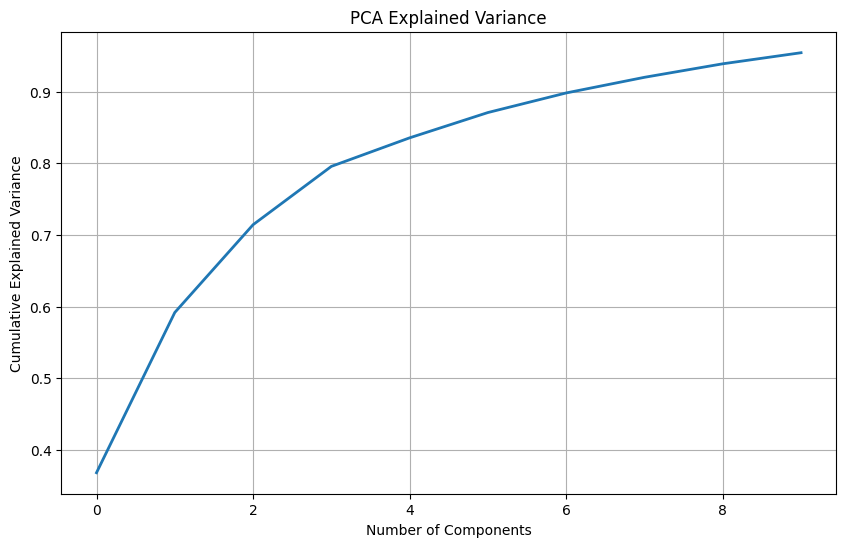

PCA Plot Saved

Generating correlation heatmap...


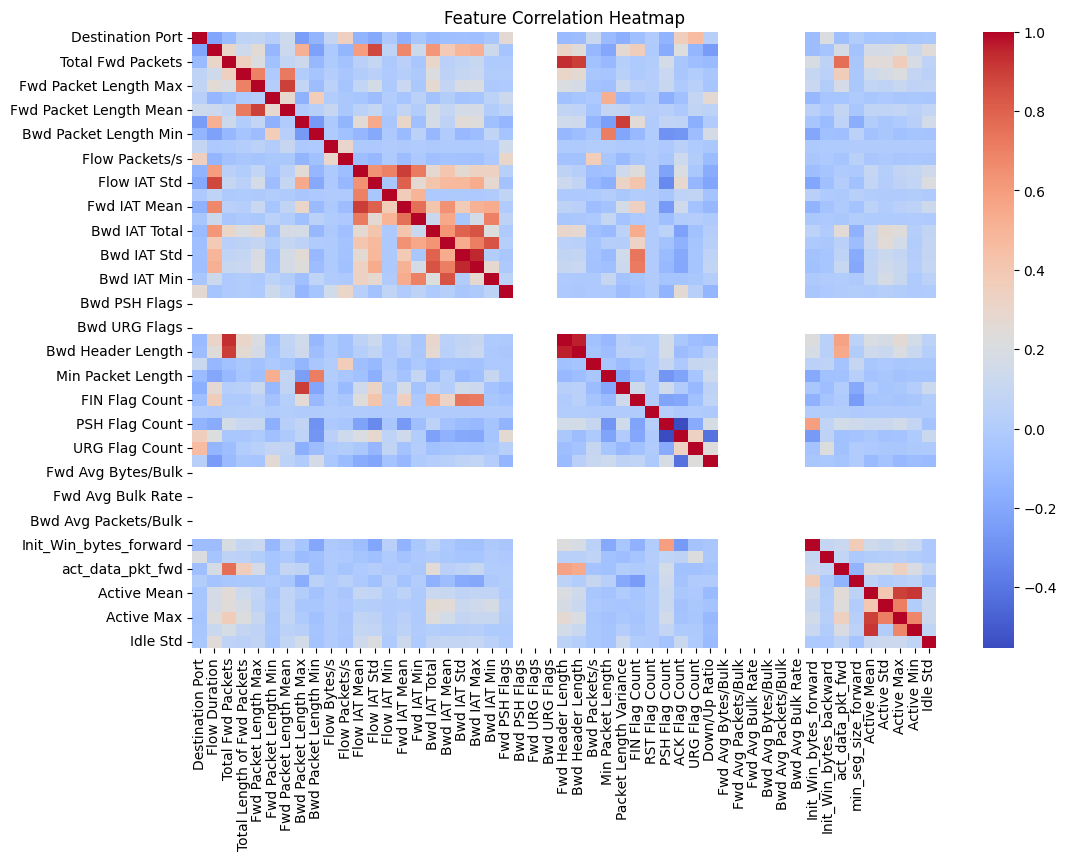

Heatmap Saved

STEP 4 COMPLETED SUCCESSFULLY
Original Features : 78
After Correlation : 51
After PCA : 10


In [6]:
# ============================================================
# STEP 4 — FEATURE ENGINEERING
# Correlation Analysis + PCA
# ============================================================

print("=" * 60)
print("STEP 4 — FEATURE ENGINEERING")
print("=" * 60)

# ------------------------------------------------
# 1. Correlation Analysis
# ------------------------------------------------
print("\nCalculating correlation matrix...")

correlation_matrix = X_scaled.corr().abs()

print("Correlation matrix created")


# ------------------------------------------------
# 2. Remove Highly Correlated Features
# Threshold = 0.95
# ------------------------------------------------
print("\nRemoving highly correlated features...")

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

print(f"Highly correlated features found: {len(high_corr_features)}")

X_selected = X_scaled.drop(
    columns=high_corr_features,
    errors='ignore'
)

print("Original Feature Count :", X_scaled.shape[1])
print("Selected Feature Count :", X_selected.shape[1])


# ------------------------------------------------
# Save Removed Features
# ------------------------------------------------
removed_features_path = (
    "/kaggle/working/outputs/"
    "removed_correlated_features.csv"
)

pd.DataFrame({
    "Removed_Features": high_corr_features
}).to_csv(
    removed_features_path,
    index=False
)

print("\nRemoved Features Saved:")
print(removed_features_path)


# ------------------------------------------------
# 3. PCA (95% Variance Retained)
# ------------------------------------------------
print("\nApplying PCA...")

pca = PCA(n_components=0.95, random_state=SEED)

X_pca = pca.fit_transform(X_selected)

print("PCA completed")

print("\nOriginal Features :", X_selected.shape[1])
print("PCA Features :", X_pca.shape[1])

print(
    "Explained Variance :",
    round(np.sum(pca.explained_variance_ratio_) * 100, 2),
    "%"
)


# ------------------------------------------------
# Save PCA Dataset
# ------------------------------------------------
X_pca_df = pd.DataFrame(X_pca)

pca_path = "/kaggle/working/outputs/pca_dataset.csv"

X_pca_df.to_csv(
    pca_path,
    index=False
)

print("\nPCA Dataset Saved:")
print(pca_path)


# ------------------------------------------------
# Save PCA Model
# ------------------------------------------------
joblib.dump(
    pca,
    "/kaggle/working/models/pca_model.pkl"
)

print("PCA Model Saved")


# ------------------------------------------------
# 4. Plot PCA Explained Variance
# ------------------------------------------------
print("\nGenerating PCA plot...")

plt.figure(figsize=(10,6))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    linewidth=2
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plot_path = (
    "/kaggle/working/plots/"
    "pca_explained_variance.png"
)

plt.savefig(
    plot_path,
    bbox_inches='tight'
)

plt.show()

print("PCA Plot Saved")


# ------------------------------------------------
# 5. Correlation Heatmap
# (Sample only for visualization)
# ------------------------------------------------
print("\nGenerating correlation heatmap...")

sample_corr = X_selected.sample(
    min(5000, len(X_selected)),
    random_state=SEED
).corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    sample_corr,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

heatmap_path = (
    "/kaggle/working/plots/"
    "correlation_heatmap.png"
)

plt.savefig(
    heatmap_path,
    bbox_inches='tight'
)

plt.show()

print("Heatmap Saved")


# ------------------------------------------------
# Final Summary
# ------------------------------------------------
print("\n" + "=" * 60)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Original Features :", X_scaled.shape[1])
print("After Correlation :", X_selected.shape[1])
print("After PCA :", X_pca.shape[1])

# TRAIN/TEST SPLIT + MODEL TRAINING

In [7]:
# ============================================================
# STEP 5 — TRAIN TEST SPLIT + MODEL TRAINING
# ============================================================

print("=" * 60)
print("STEP 5 — MODEL TRAINING")
print("=" * 60)

# ------------------------------------------------
# 1. Train/Test Split
# ------------------------------------------------
print("\nSplitting data into train and test...")

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)


# ------------------------------------------------
# 2. Define Models
# ------------------------------------------------
print("\nInitializing models...")

models = {

    "Logistic Regression": LogisticRegression(
        random_state=SEED,
        max_iter=1000,
        n_jobs=-1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel='rbf',
        probability=True,
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=SEED,
        eval_metric='logloss',
        tree_method='hist'
    )
}

print("Models initialized successfully")


# ------------------------------------------------
# 3. Train Models
# ------------------------------------------------
trained_models = {}

print("\nStarting model training...\n")

for name, model in models.items():

    print("=" * 60)
    print(f"Training: {name}")
    print("=" * 60)

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} training completed")

    # Save model
    model_path = (
        f"/kaggle/working/models/"
        f"{name.replace(' ', '_').lower()}.pkl"
    )

    joblib.dump(model, model_path)

    print(f"Model saved: {model_path}")


print("\n" + "=" * 60)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 60)


# ------------------------------------------------
# 4. Save Train/Test Data
# ------------------------------------------------
joblib.dump(X_test, "/kaggle/working/outputs/X_test.pkl")
joblib.dump(y_test, "/kaggle/working/outputs/y_test.pkl")

print("\nTest data saved")


# ------------------------------------------------
# Final Summary
# ------------------------------------------------
print("\nModels Trained:")
for model_name in trained_models.keys():
    print("✓", model_name)

STEP 5 — MODEL TRAINING

Splitting data into train and test...
Train Shape: (681185, 10)
Test Shape : (170297, 10)

Initializing models...
Models initialized successfully

Starting model training...

Training: Logistic Regression
Logistic Regression training completed
Model saved: /kaggle/working/models/logistic_regression.pkl
Training: Random Forest
Random Forest training completed
Model saved: /kaggle/working/models/random_forest.pkl
Training: SVM
SVM training completed
Model saved: /kaggle/working/models/svm.pkl
Training: XGBoost
XGBoost training completed
Model saved: /kaggle/working/models/xgboost.pkl

ALL MODELS TRAINED SUCCESSFULLY

Test data saved

Models Trained:
✓ Logistic Regression
✓ Random Forest
✓ SVM
✓ XGBoost


# MODEL EVALUATION

STEP 6 — MODEL EVALUATION

Evaluating: Logistic Regression
Accuracy : 0.8211
Precision: 0.8121
Recall   : 0.8355
F1 Score : 0.8236
FPR      : 0.1932
ROC-AUC  : 0.9340
Classification report saved


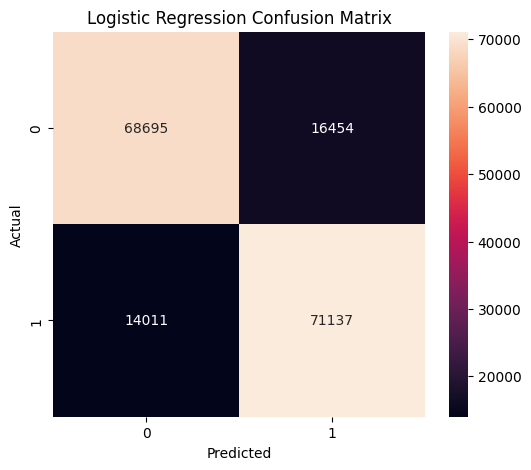

Confusion matrix saved


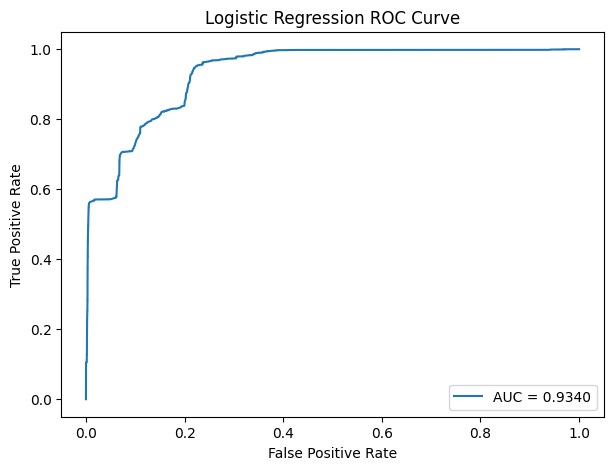

ROC curve saved

Evaluating: Random Forest
Accuracy : 0.9879
Precision: 0.9861
Recall   : 0.9897
F1 Score : 0.9879
FPR      : 0.0140
ROC-AUC  : 0.9985
Classification report saved


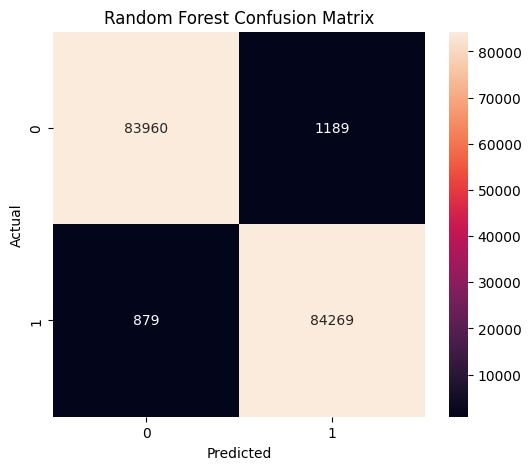

Confusion matrix saved


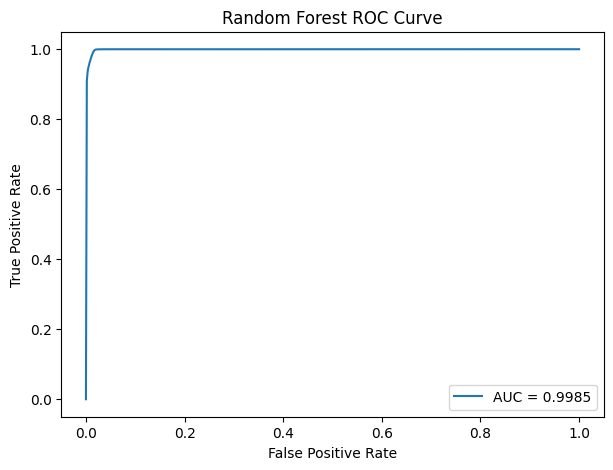

ROC curve saved

Evaluating: SVM
Accuracy : 0.9563
Precision: 0.9388
Recall   : 0.9763
F1 Score : 0.9572
FPR      : 0.0637
ROC-AUC  : 0.9912
Classification report saved


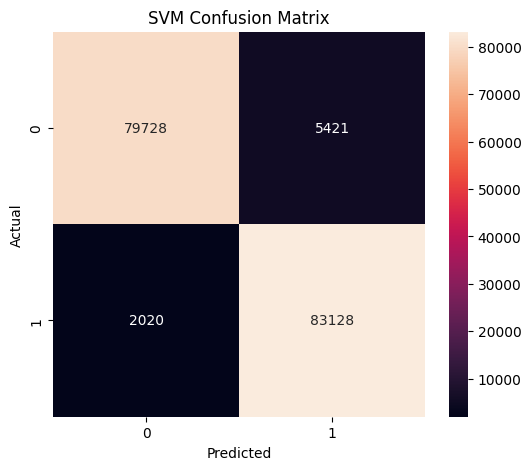

Confusion matrix saved


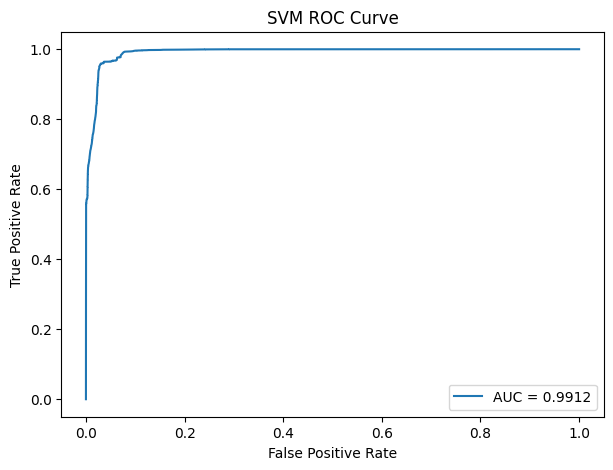

ROC curve saved

Evaluating: XGBoost
Accuracy : 0.9833
Precision: 0.9743
Recall   : 0.9929
F1 Score : 0.9835
FPR      : 0.0262
ROC-AUC  : 0.9984
Classification report saved


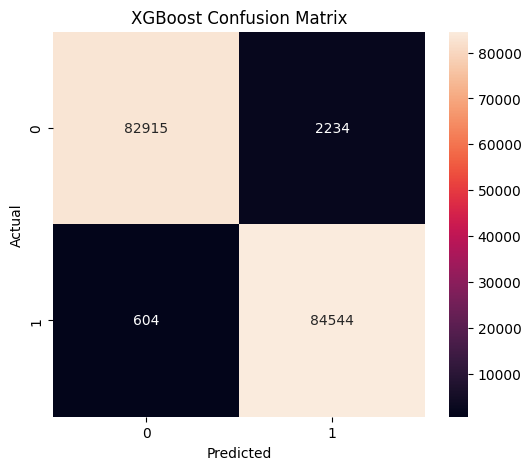

Confusion matrix saved


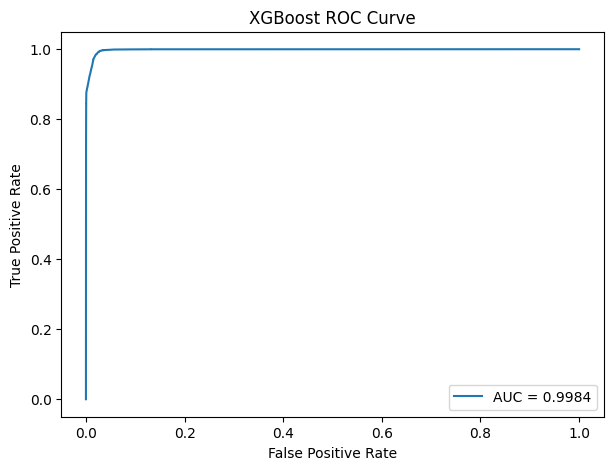

ROC curve saved

MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1 Score,False Positive Rate,ROC-AUC
1,Random Forest,0.987857,0.986087,0.989677,0.987879,0.013964,0.998462
3,XGBoost,0.983335,0.974256,0.992906,0.983493,0.026236,0.998418
2,SVM,0.956306,0.938780,0.976277,0.957161,0.063665,0.991214
0,Logistic Regression,0.821107,0.812150,0.835451,0.823636,0.193238,0.933955



Results saved:
/kaggle/working/outputs/model_results.csv

Best Model: Random Forest
Best F1 Score: 0.9879
Best model saved


<Figure size 1000x600 with 0 Axes>

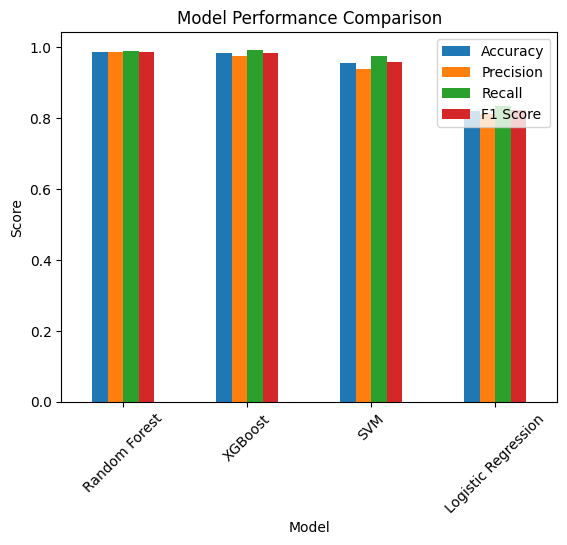


Comparison graph saved

STEP 6 COMPLETED SUCCESSFULLY
Best Performing Model: Random Forest


In [8]:
# ============================================================
# STEP 6 — MODEL EVALUATION
# ============================================================

print("=" * 60)
print("STEP 6 — MODEL EVALUATION")
print("=" * 60)

# ------------------------------------------------
# Store Results
# ------------------------------------------------
results = []

best_model = None
best_f1 = 0


# ------------------------------------------------
# Evaluate Each Model
# ------------------------------------------------
for name, model in trained_models.items():

    print("\n" + "=" * 60)
    print(f"Evaluating: {name}")
    print("=" * 60)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # False Positive Rate
    fpr = fp / (fp + tn)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"FPR      : {fpr:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    # Save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "False Positive Rate": fpr,
        "ROC-AUC": roc_auc
    })

    # Save Classification Report
    report = classification_report(
        y_test,
        y_pred
    )

    report_path = (
        f"/kaggle/working/outputs/"
        f"{name.replace(' ', '_').lower()}_report.txt"
    )

    with open(report_path, "w") as f:
        f.write(report)

    print("Classification report saved")


    # ------------------------------------------------
    # Confusion Matrix Plot
    # ------------------------------------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d'
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    cm_path = (
        f"/kaggle/working/plots/"
        f"{name.replace(' ', '_').lower()}_cm.png"
    )

    plt.savefig(
        cm_path,
        bbox_inches='tight'
    )

    plt.show()

    print("Confusion matrix saved")


    # ------------------------------------------------
    # ROC Curve
    # ------------------------------------------------
    fpr_curve, tpr_curve, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.figure(figsize=(7,5))

    plt.plot(
        fpr_curve,
        tpr_curve,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curve")

    plt.legend()

    roc_path = (
        f"/kaggle/working/plots/"
        f"{name.replace(' ', '_').lower()}_roc.png"
    )

    plt.savefig(
        roc_path,
        bbox_inches='tight'
    )

    plt.show()

    print("ROC curve saved")

    # ------------------------------------------------
    # Best Model Selection
    # ------------------------------------------------
    if f1 > best_f1:
        best_f1 = f1
        best_model = name


# ------------------------------------------------
# Results DataFrame
# ------------------------------------------------
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)

print("\n" + "=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)

display(results_df)


# ------------------------------------------------
# Save Results CSV
# ------------------------------------------------
results_path = (
    "/kaggle/working/outputs/model_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("\nResults saved:")
print(results_path)


# ------------------------------------------------
# Save Best Model
# ------------------------------------------------
best_model_object = trained_models[best_model]

joblib.dump(
    best_model_object,
    "/kaggle/working/models/best_model.pkl"
)

print("\nBest Model:", best_model)
print("Best F1 Score:", round(best_f1, 4))
print("Best model saved")


# ------------------------------------------------
# Model Comparison Plot
# ------------------------------------------------
plt.figure(figsize=(10,6))

comparison_metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]

results_df.set_index("Model")[
    comparison_metrics
].plot(kind='bar')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)

comparison_path = (
    "/kaggle/working/plots/"
    "model_comparison.png"
)

plt.savefig(
    comparison_path,
    bbox_inches='tight'
)

plt.show()

print("\nComparison graph saved")


# ------------------------------------------------
# Final Summary
# ------------------------------------------------
print("\n" + "=" * 60)
print("STEP 6 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Best Performing Model:", best_model)

# SHAP EXPLAINABILITY

STEP 7 — EXPLAINABLE AI

Preparing data for explainability...
Train Shape: (681185, 51)
Test Shape : (170297, 51)

Retraining best model for explainability...
Model retrained successfully

Preparing sample data...
Sample Shape: (2000, 51)

Generating SHAP values...
SHAP values generated successfully

Generating SHAP Summary Plot...


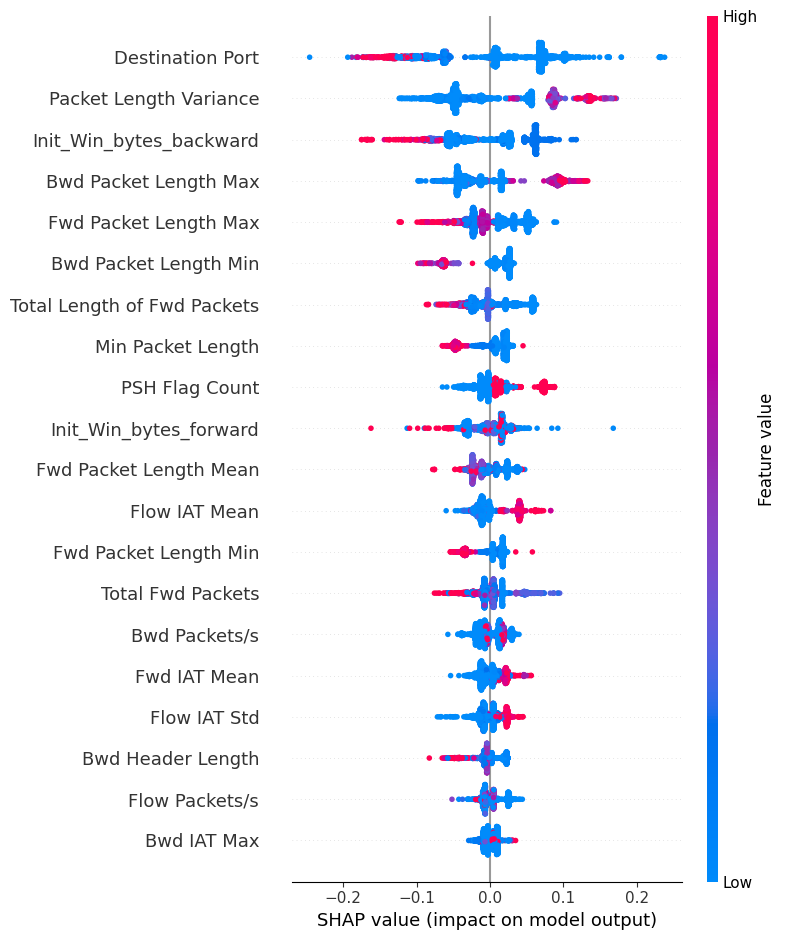

Summary plot saved

Generating Feature Importance Plot...


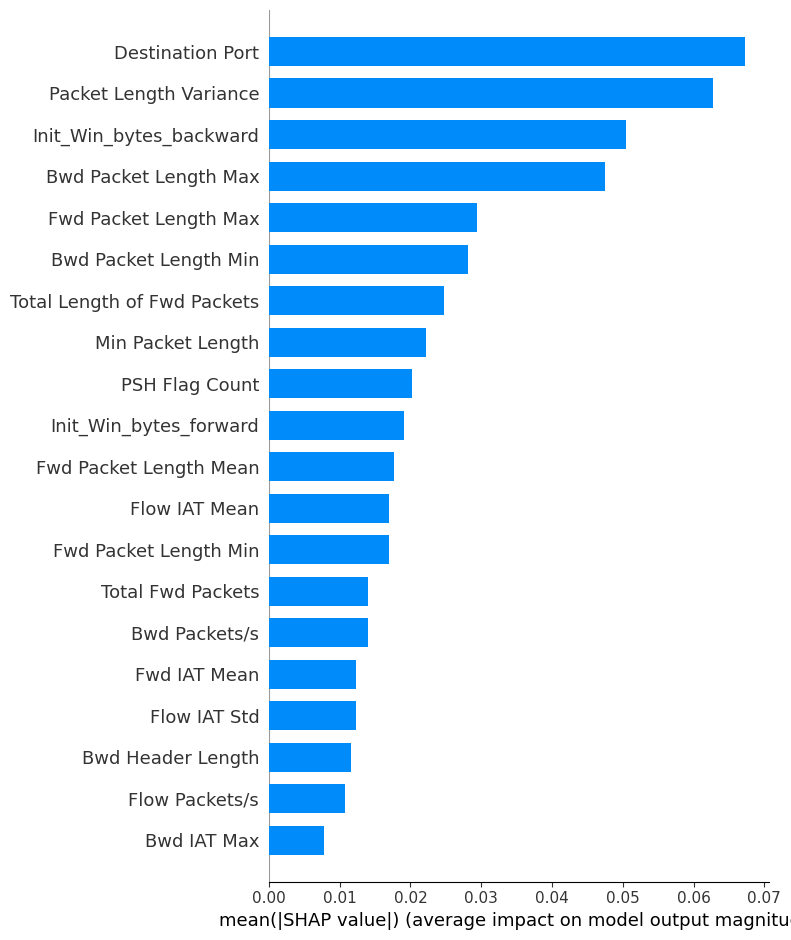

Feature importance plot saved

Saving feature importance...
Feature importance saved

Top 10 Important Features


,Feature,Importance
0,Destination Port,0.067301
29,Packet Length Variance,0.062694
43,Init_Win_bytes_backward,0.050435
7,Bwd Packet Length Max,0.047438
4,Fwd Packet Length Max,0.029386
8,Bwd Packet Length Min,0.028177
3,Total Length of Fwd Packets,0.024725
28,Min Packet Length,0.022137
32,PSH Flag Count,0.020179
42,Init_Win_bytes_forward,0.019098



STEP 7 COMPLETED SUCCESSFULLY
Best Model Explained: Random Forest
Outputs Saved in:
/kaggle/working/plots/
/kaggle/working/outputs/


In [9]:
# ============================================================
# STEP 7 — EXPLAINABLE AI (FIXED SHAP VERSION)
# ============================================================

import shap

print("=" * 60)
print("STEP 7 — EXPLAINABLE AI")
print("=" * 60)

# ------------------------------------------------
# 1. Recreate Train/Test Split
# Using original features
# ------------------------------------------------
print("\nPreparing data for explainability...")

X_train_xai, X_test_xai, y_train_xai, y_test_xai = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train Shape:", X_train_xai.shape)
print("Test Shape :", X_test_xai.shape)


# ------------------------------------------------
# 2. Retrain Best Model
# ------------------------------------------------
print("\nRetraining best model for explainability...")

best_model_name = best_model

if best_model_name == "Random Forest":

    xai_model = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    )

elif best_model_name == "XGBoost":

    xai_model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=SEED,
        eval_metric='logloss'
    )

elif best_model_name == "Logistic Regression":

    xai_model = LogisticRegression(
        max_iter=1000,
        random_state=SEED
    )

else:

    xai_model = SVC(
        probability=True,
        random_state=SEED
    )

xai_model.fit(X_train_xai, y_train_xai)

print("Model retrained successfully")


# ------------------------------------------------
# 3. Sample Data
# ------------------------------------------------
print("\nPreparing sample data...")

sample_size = 2000

X_sample = X_test_xai.sample(
    min(sample_size, len(X_test_xai)),
    random_state=SEED
)

print("Sample Shape:", X_sample.shape)


# ------------------------------------------------
# 4. Create SHAP Explainer
# ------------------------------------------------
print("\nGenerating SHAP values...")

# Tree models
if best_model_name in ["Random Forest", "XGBoost"]:

    explainer = shap.TreeExplainer(xai_model)
    shap_values = explainer.shap_values(X_sample)

    # Fix for newer SHAP versions
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values[:, :, 1]

# Non-tree models
else:

    explainer = shap.Explainer(
        xai_model.predict,
        X_sample
    )

    shap_values = explainer(X_sample)
    shap_values_plot = shap_values.values

print("SHAP values generated successfully")


# ------------------------------------------------
# 5. SHAP Summary Plot
# ------------------------------------------------
print("\nGenerating SHAP Summary Plot...")

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values_plot,
    X_sample,
    show=False
)

summary_path = (
    "/kaggle/working/plots/"
    "shap_summary.png"
)

plt.savefig(
    summary_path,
    bbox_inches='tight'
)

plt.show()

print("Summary plot saved")


# ------------------------------------------------
# 6. SHAP Bar Plot
# ------------------------------------------------
print("\nGenerating Feature Importance Plot...")

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values_plot,
    X_sample,
    plot_type="bar",
    show=False
)

bar_path = (
    "/kaggle/working/plots/"
    "shap_bar_plot.png"
)

plt.savefig(
    bar_path,
    bbox_inches='tight'
)

plt.show()

print("Feature importance plot saved")


# ------------------------------------------------
# 7. Save Feature Importance CSV
# ------------------------------------------------
print("\nSaving feature importance...")

importance_values = np.abs(
    shap_values_plot
).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "Importance": importance_values
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_path = (
    "/kaggle/working/outputs/"
    "feature_importance_xai.csv"
)

importance_df.to_csv(
    importance_path,
    index=False
)

print("Feature importance saved")


# ------------------------------------------------
# 8. Show Top Features
# ------------------------------------------------
print("\nTop 10 Important Features")

display(importance_df.head(10))


# ------------------------------------------------
# Final Summary
# ------------------------------------------------
print("\n" + "=" * 60)
print("STEP 7 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Best Model Explained:", best_model_name)
print("Outputs Saved in:")
print("/kaggle/working/plots/")
print("/kaggle/working/outputs/")

# FINAL IDS SECURITY ALARM SYSTEM

In [10]:
# ============================================================
# STEP 8 — FINAL IDS SECURITY ALARM SYSTEM
# ============================================================

print("=" * 60)
print("STEP 8 — INTRUSION DETECTION SYSTEM")
print("=" * 60)

# ------------------------------------------------
# Load Best Model
# ------------------------------------------------
print("\nLoading best model...")

best_model_loaded = joblib.load(
    "/kaggle/working/models/best_model.pkl"
)

print("Best model loaded successfully")


# ------------------------------------------------
# Function for IDS Prediction
# ------------------------------------------------
def intrusion_detection_system(sample_index):

    print("\n" + "=" * 60)
    print("INTRUSION DETECTION ANALYSIS")
    print("=" * 60)

    # Get sample
    sample = X_test[sample_index].reshape(1, -1)

    actual_label = y_test.iloc[sample_index]

    # Prediction
    prediction = best_model_loaded.predict(sample)[0]

    probability = best_model_loaded.predict_proba(sample)[0]

    attack_prob = probability[1]
    benign_prob = probability[0]

    print(f"\nSample Index: {sample_index}")

    print("\nPrediction Probabilities")
    print(f"Benign Probability : {benign_prob:.4f}")
    print(f"Attack Probability : {attack_prob:.4f}")

    print("\nActual Label:",
          "ATTACK" if actual_label == 1 else "BENIGN")

    print("Predicted Label:",
          "ATTACK" if prediction == 1 else "BENIGN")

    # ------------------------------------------------
    # Security Alarm
    # ------------------------------------------------
    if prediction == 1:

        print("\n🚨 SECURITY ALERT 🚨")
        print("Malicious network activity detected!")
        print("Potential intrusion found.")

    else:

        print("\n✅ SAFE TRAFFIC")
        print("Normal network behavior detected.")

    return {
        "sample_index": sample_index,
        "actual_label": actual_label,
        "prediction": prediction,
        "attack_probability": attack_prob,
        "benign_probability": benign_prob
    }


# ------------------------------------------------
# Test IDS on Random Samples
# ------------------------------------------------
print("\nTesting IDS on random samples...\n")

results_predictions = []

for i in random.sample(
    range(len(X_test)),
    10
):

    result = intrusion_detection_system(i)

    results_predictions.append(result)


# ------------------------------------------------
# Save Prediction Results
# ------------------------------------------------
predictions_df = pd.DataFrame(
    results_predictions
)

prediction_path = (
    "/kaggle/working/outputs/"
    "ids_predictions.csv"
)

predictions_df.to_csv(
    prediction_path,
    index=False
)

print("\nPredictions saved:")
print(prediction_path)


# ------------------------------------------------
# Final Summary
# ------------------------------------------------
print("\n" + "=" * 60)
print("STEP 8 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Intrusion Detection System Ready")
print("Security Alarm System Active")

STEP 8 — INTRUSION DETECTION SYSTEM

Loading best model...
Best model loaded successfully

Testing IDS on random samples...


INTRUSION DETECTION ANALYSIS

Sample Index: 167621

Prediction Probabilities
Benign Probability : 0.0000
Attack Probability : 1.0000

Actual Label: ATTACK
Predicted Label: ATTACK

🚨 SECURITY ALERT 🚨
Malicious network activity detected!
Potential intrusion found.

INTRUSION DETECTION ANALYSIS

Sample Index: 29184

Prediction Probabilities
Benign Probability : 1.0000
Attack Probability : 0.0000

Actual Label: BENIGN
Predicted Label: BENIGN

✅ SAFE TRAFFIC
Normal network behavior detected.

INTRUSION DETECTION ANALYSIS

Sample Index: 6556

Prediction Probabilities
Benign Probability : 1.0000
Attack Probability : 0.0000

Actual Label: BENIGN
Predicted Label: BENIGN

✅ SAFE TRAFFIC
Normal network behavior detected.

INTRUSION DETECTION ANALYSIS

Sample Index: 72097

Prediction Probabilities
Benign Probability : 0.2000
Attack Probability : 0.8000

Actual Label: ATTACK